# Trabajo Práctico NLP — *Cabeza de Equipo*
## Un asistente con RAG de preparación psicológica para jóvenes futbolistas

**Integrantes:** Ezequiel Suñer - Thomas Palacio

**Materia:** Aprendizaje Automático II

---

### De qué se trata

Un futbolista juvenil que se pone nervioso antes de un partido, que no se recupera de un error,
que perdió la motivación en el banco o que no sabe cómo compaginar el club con el estudio tiene
básicamente dos opciones: arreglárselas solo, o pagar un psicólogo deportivo. La segunda está
fuera del alcance de la enorme mayoría.

Al mismo tiempo, existe literatura científica en español que estudia
exactamente esos problemas y describe programas de intervención concretos: cuántas semanas, qué
técnicas, con qué resultados. El problema es el formato: ningún chico de 16 años va a leer un
paper.

**Este asistente hace de puente.** Recupera los fragmentos relevantes de un corpus de artículos
científicos sobre psicología del deporte aplicada al fútbol formativo y responde en lenguaje
llano, fundado en esa evidencia y sin inventar.

> **Limitación declarada.** Es una herramienta de orientación y divulgación. No reemplaza el
> acompañamiento de un profesional de la salud mental y no debe usarse frente a señales de
> malestar clínico.

---

### Índice

| Fase | Contenido |
|---|---|
| 0 | Setup e instalación |
| 1 | Corpus: carga, extracción, limpieza, estadísticas y dos estrategias de chunking |
| 2 | Embeddings e índice FAISS |
| 3 | Evaluación del retrieval con `hit@k` |
| 4 | Generación con LLM: CON RAG vs SIN RAG |
| 5 | Reporte final |

---

### Cómo correrlo

1. **Activar GPU:** `Entorno de ejecución → Cambiar tipo de entorno → T4 GPU`.
2. **Subir los PDFs** cuando lo pida la celda 1.2.
3. `Entorno de ejecución → Reiniciar y ejecutar todo`.

Los modelos que se usan (`paraphrase-multilingual-mpnet-base-v2` y `Qwen2.5-1.5B-Instruct`).

---

# Fase 0 — Setup

In [1]:
!pip install -q pymupdf sentence-transformers faiss-cpu transformers accelerate

print("Instalacion terminada.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 54.5 MB/s eta 0:00:00
Instalacion terminada.


In [2]:
import os, re, json, textwrap, statistics, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Configuracion central: todos los parametros del TP en un solo lugar, asi
# probar otra configuracion es cambiar un numero y volver a ejecutar.
# ---------------------------------------------------------------------------
CONFIG = {
    # Fase 1 - chunking
    "fixed_size":      800,   # caracteres por chunk en la estrategia A
    "fixed_overlap":   100,   # solapamiento entre chunks consecutivos
    "par_max":         800,   # tamano maximo de un chunk paragraph-aware
    "par_min":         200,   # descarta fragmentos mas cortos que esto

    # Fase 2 - embeddings
    "embedder": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",

    # Fase 3 - evaluacion
    "k_values": [1, 3, 5],

    # Fase 4 - generacion
    "llm":        "Qwen/Qwen2.5-1.5B-Instruct",
    "k_rag":      4,     # cuantos chunks recibe el LLM como contexto
    "max_tokens": 350,

    "seed": 42,
}

np.random.seed(CONFIG["seed"])

DIR_PDFS = "pdfs"
os.makedirs(DIR_PDFS, exist_ok=True)

# Paleta de graficos (par validado para daltonismo)
C_AZUL, C_NARANJA = "#2a78d6", "#eb6834"
C_TINTA, C_MUTED, C_GRILLA = "#0b0b0b", "#898781", "#e1e0d9"

pd.set_option("display.max_colwidth", 90)
print("Configuracion cargada.")

Configuracion cargada.


---

# Fase 1 — Corpus y chunking

## 1.1 El corpus

Artículos científicos en español, de acceso abierto, sobre psicología del deporte aplicada al
fútbol formativo. Cada artículo es **un documento**: es la unidad de trazabilidad con la que se
anotan las preguntas y se mide el `hit@k`.

| id | Artículo | Eje |
|---|---|---|
| `iberoam_intervencion` | Navarrón et al. (2017). *Implementación de una intervención psicológica en fútbol base, satisfacción subjetiva de los deportistas y experiencias de pasión, competencia percibida y compromiso deportivo*. Rev. Iberoamericana de Psicología del Ejercicio y el Deporte, 12(1) | B — Habilidades psicológicas |
| `cpd_burnout` | De Francisco et al. (2009). *Propiedades psicométricas preliminares de la versión española del Athlete Burnout Questionnaire en una muestra de jóvenes futbolistas*. Cuadernos de Psicología del Deporte, 9(2) | D — Burnout |
| `anales_bayesiano` | Garcia-Mas et al. (2015). *Análisis bayesiano de la motivación, el clima motivacional y la ansiedad en jóvenes jugadores de equipo*. Anales de Psicología, 31(1) | C — Motivación y clima |
| `sportis_motiv_ansied` | Arroyo del Bosque et al. (2025). *Motivación y ansiedad en el fútbol formativo: claves para el desarrollo psicológico en categorías alevín e infantil*. Sportis, 11(3) | A — Ansiedad precompetitiva |
| `ariza_fisio_psico_futbol` | León Ariza, Sánchez Jiménez y Ramírez Villada (2011). *Demandas fisiológicas y psicológicas en el fútbol*. Cuerpo, Cultura y Movimiento, 1(2), 41-55 | E — Demandas fisiológicas y psicológicas (marco general) |

### Por qué este corpus

**El modelo generador no lo conoce.** Qwen2.5-1.5B-Instruct es chico y estos artículos son
material de nicho. Ante *"¿cuántas semanas duró la intervención psicológica?"* no tiene forma de
saberlo — pero igual va a responder, inventando un número. Eso hace que la comparación de la
Fase 4 muestre un contraste medible en lugar de la tabla plana que sale con corpus que el modelo
ya memorizó.

**La estructura favorece la comparación de chunkings.** Un paper tiene bloques semánticos
rígidos: Resumen / Introducción / Método (Participantes, Instrumentos, Procedimiento) /
Resultados / Discusión. Paragraph-aware puede respetarlos; fixed-size corta tablas y parte frases
con datos numéricos al medio.

**Las respuestas son verificables.** Un `n` muestral, un rango de edades, el nombre de un
instrumento: o está en el documento o no está. Eso permite anotar el set de evaluación sin
ambigüedad y juzgar las alucinaciones sin discusión.

**Por qué León Ariza et al. va en un eje propio (E) y no en el B.** Los otros cuatro artículos son estudios empíricos con su propia muestra (un `n`, un instrumento, un procedimiento). León Ariza, Sánchez Jiménez y Ramírez Villada (2011) es distinto: es un **artículo de revisión** que sintetiza hallazgos de docenas de estudios previos sobre demandas fisiológicas (VO₂ máx., distancia recorrida, gasto calórico, umbral anaeróbico) y psicológicas (activación, atención, afrontamiento, autoconfianza) del fútbol. Forzarlo dentro del eje B (habilidades psicológicas) sería impreciso — cubre fisiología además de psicología, y no describe ninguna intervención — así que se lo clasifica en un eje E nuevo.

**Una consecuencia para el diseño de preguntas.** Al ser una revisión, el propio texto cita varias muestras distintas dentro de un mismo documento (219 futbolistas en un estudio costarricense, 40 en uno chileno, 399 en uno italiano). Una pregunta como *"¿cuántos jugadores participaron en el estudio?"* sería ambigua **incluso dentro de este único documento**, no sólo entre documentos — el mismo cuidado que ya se tenía con Navarrón vs. Olmedilla hay que aplicarlo puertas adentro de este artículo: cada pregunta sobre él debe anclarse al estudio específico citado (p. ej. "el estudio costarricense"), no preguntar el dato de forma genérica.

**Una nota sobre la extracción (Fase 1.3-1.4).** Este PDF viene de una revista con una columna lateral decorativa: el nombre de la revista y de la sección aparecen impresos en vertical, letra por letra, en el margen de cada página — a diferencia de los otros cuatro, ese ruido no está confinado al 7%/93% superior e inferior que descarta `extraer_bloques`, porque corre por el costado de la página completa. La expectativa es que `quitar_repetidos` lo filtre igual, porque son fragmentos cortos (una o pocas letras) que se repiten en casi todas las páginas — pero al no haber podido correr el pipeline real sobre este PDF (sin PyMuPDF ni conexión disponibles en este entorno), conviene que al ejecutar la celda 13 (verificación) revisen especialmente este documento: si aparecen fragmentos sueltos tipo "C", "u", "erp" colados en el texto, es señal de que ese ruido lateral no se filtró del todo y hace falta un descarte adicional por longitud mínima de bloque.

Los requisitos del enunciado —mínimo 60.000 caracteres y 5 documentos— siguen cubiertos: el total real (que puede diferir del que se reportaba con Olmedilla) se recalcula automáticamente al correr la sección 1.5 de este mismo notebook; no hace falta editarlo a mano.



In [3]:
# ---------------------------------------------------------------------------
# CORPUS. El campo "archivo" tiene que coincidir con el nombre del PDF subido.
# Para sumar un documento: agregar una entrada aca y subir su PDF.
# ---------------------------------------------------------------------------
CORPUS = [
    {"id": "iberoam_intervencion",
     "archivo": "iberoam_intervencion.pdf",
     "titulo": "Implementacion de una intervencion psicologica en futbol base, satisfaccion "
               "subjetiva de los deportistas y experiencias de pasion, competencia percibida "
               "y compromiso deportivo",
     "autores": "Navarron, Godoy-Izquierdo, Velez, Ramirez-Molina y Jimenez-Torres (2017)",
     "fuente": "Revista Iberoamericana de Psicologia del Ejercicio y el Deporte, 12(1), 59-69",
     "eje": "B"},

    {"id": "cpd_burnout",
     "archivo": "cpd_burnout.pdf",
     "titulo": "Propiedades psicometricas preliminares de la version espanola del Athlete "
               "Burnout Questionnaire en una muestra de jovenes futbolistas",
     "autores": "De Francisco, Arce, Andrade, Arce y Raedeke (2009)",
     "fuente": "Cuadernos de Psicologia del Deporte, 9(2), 45-56",
     "eje": "D"},

    {"id": "anales_bayesiano",
     "archivo": "anales_bayesiano.pdf",
     "titulo": "Analisis bayesiano de la motivacion, el clima motivacional y la ansiedad en "
               "jovenes jugadores de equipo",
     "autores": "Garcia-Mas, Fuster-Parra, Ponseti, Palou, Olmedilla y Cruz (2015)",
     "fuente": "Anales de Psicologia, 31(1), 355-366",
     "eje": "C"},

    {"id": "sportis_motiv_ansied",
     "archivo": "sportis_motiv_ansied.pdf",
     "titulo": "Motivacion y ansiedad en el futbol formativo: claves para el desarrollo "
               "psicologico en categorias alevin e infantil",
     "autores": "Arroyo del Bosque, Cook Vaquero, Moral Garcia y Amatria Jimenez (2025)",
     "fuente": "Sportis Sci J, 11(3), 1-26",
     "eje": "A"},

    # A diferencia de los otros cuatro, este es un articulo de REVISION (no un estudio
    # empirico propio): sintetiza hallazgos fisiologicos y psicologicos de decenas de
    # estudios previos. Por eso va en un eje propio (E) en vez de forzarlo dentro de B.
    {"id": "ariza_fisio_psico_futbol",
     "archivo": "ariza_fisio_psico_futbol.pdf",
     "titulo": "Demandas fisiologicas y psicologicas en el futbol",
     "autores": "Leon Ariza, Sanchez Jimenez y Ramirez Villada (2011)",
     "fuente": "Cuerpo, Cultura y Movimiento, 1(2), 41-55",
     "eje": "E"},
]

print(f"{len(CORPUS)} documentos definidos.")
if len(CORPUS) < 5:
    print(f"ATENCION: el enunciado pide minimo 5 documentos. Faltan {5 - len(CORPUS)}.")
pd.DataFrame(CORPUS)[["id", "eje", "autores", "fuente"]]

5 documentos definidos.


,id,eje,autores,fuente
0,iberoam_intervencion,B,"Navarron, Godoy-Izquierdo, Velez, Ramirez-Molina y Jimenez-Torres (2017)","Revista Iberoamericana de Psicologia del Ejercicio y el Deporte, 12(1), 59-69"
1,cpd_burnout,D,"De Francisco, Arce, Andrade, Arce y Raedeke (2009)","Cuadernos de Psicologia del Deporte, 9(2), 45-56"
2,anales_bayesiano,C,"Garcia-Mas, Fuster-Parra, Ponseti, Palou, Olmedilla y Cruz (2015)","Anales de Psicologia, 31(1), 355-366"
3,sportis_motiv_ansied,A,"Arroyo del Bosque, Cook Vaquero, Moral Garcia y Amatria Jimenez (2025)","Sportis Sci J, 11(3), 1-26"
4,ariza_fisio_psico_futbol,E,"Leon Ariza, Sanchez Jimenez y Ramirez Villada (2011)","Cuerpo, Cultura y Movimiento, 1(2), 41-55"


## 1.2 Carga de los PDFs

Subí los cinco PDFs. Los nombres tienen que coincidir con el campo `archivo` de `CORPUS` (alineado con el `id` de cada documento); si alguno no coincide, la celda avisa cuál falta.

In [4]:
def pdfs_presentes():
    return {d["archivo"]: os.path.join(DIR_PDFS, d["archivo"])
            for d in CORPUS
            if os.path.exists(os.path.join(DIR_PDFS, d["archivo"]))}

if len(pdfs_presentes()) < len(CORPUS):
    try:
        from google.colab import files
        print("Subi los PDFs del corpus:\n")
        subidos = files.upload()
        for nombre in subidos:
            os.replace(nombre, os.path.join(DIR_PDFS, nombre))
        print()
    except ImportError:
        print(f"Fuera de Colab: copiar los PDFs a ./{DIR_PDFS}/\n")

documentos, faltantes = [], []
for d in CORPUS:
    ruta = os.path.join(DIR_PDFS, d["archivo"])
    if os.path.exists(ruta):
        d["ruta"] = ruta
        documentos.append(d)
        print(f"  OK     {d['id']:24s} {os.path.getsize(ruta)//1024:5d} KB")
    else:
        faltantes.append(d["archivo"])
        print(f"  FALTA  {d['id']:24s} -> {d['archivo']}")

print(f"\n{len(documentos)} de {len(CORPUS)} documentos cargados.")
if faltantes:
    print("Archivos que faltan subir:", ", ".join(faltantes))

  OK     iberoam_intervencion       366 KB
  OK     cpd_burnout                141 KB
  OK     anales_bayesiano           416 KB
  OK     sportis_motiv_ansied       667 KB
  OK     ariza_fisio_psico_futbol   282 KB

5 de 5 documentos cargados.


## 1.3 Extracción de texto

Acá hay dos decisiones que importan más de lo que parecen.

**Extraemos por bloques, no por texto plano.** Pedirle a PyMuPDF el texto de cada página de
corrido devuelve **líneas**, y ahí se pierde exactamente la estructura que la estrategia
paragraph-aware necesita para existir. `get_text("blocks")` devuelve los bloques que PyMuPDF
detecta en el layout, con sus coordenadas. Eso da dos cosas: bloques que aproximan párrafos, y
posiciones que permiten **descartar headers y footers por su ubicación** (el 7% superior e
inferior de cada página, donde viven el nombre de la revista, el DOI y el número de página).

**Reconstruimos párrafos cuando el PDF viene fragmentado.** Algunos PDFs devuelven un bloque por
renglón en vez de uno por párrafo. En este corpus pasa: uno de los cuatro artículos se extrae en
755 bloques de ~80 caracteres. Si no se corrige, la estrategia B agruparía renglones sueltos y la
comparación de chunkings mediría ruido en lugar de estructura.

La detección es por mediana: si la mediana de los bloques está por debajo de 150 caracteres, el
PDF vino a nivel de línea. La reconstrucción usa una regla simple y robusta: **un párrafo nuevo
empieza sólo cuando el bloque anterior cerró una oración** (termina en `.`, `!`, `?`, `:` o `;`)
**y el siguiente arranca en mayúscula.** En cualquier otro caso la oración sigue, así que los
bloques se unen. En el artículo fragmentado esto reconstruye 127 párrafos de ~418 caracteres de
mediana, que es un tamaño de párrafo plausible.

In [5]:
import pymupdf

def extraer_bloques(ruta, margen_sup=0.07, margen_inf=0.93):
    """Extrae bloques de texto de un PDF descartando headers/footers por posicion."""
    doc = pymupdf.open(ruta)
    bloques_texto = []
    for pagina in doc:
        alto = pagina.rect.height
        bloques = sorted(pagina.get_text("blocks"), key=lambda b: (round(b[1] / 10), b[0]))
        for b in bloques:
            y0, y1, texto, tipo = b[1], b[3], b[4], b[6]
            if tipo != 0:                                     # 0 = texto, 1 = imagen
                continue
            if y1 < alto * margen_sup or y0 > alto * margen_inf:
                continue                                      # header / footer
            texto = texto.strip()
            if not texto or re.fullmatch(r"[\d\s\-–—]+", texto):
                continue                                      # numero de pagina suelto
            bloques_texto.append(texto)
    doc.close()
    return bloques_texto


def reunir_lineas(bloques, umbral_mediana=150):
    """Si el PDF devolvio bloques a nivel de linea, los reagrupa en parrafos."""
    largos = [len(b) for b in bloques]
    if not largos or statistics.median(largos) >= umbral_mediana:
        return bloques, False                                 # ya venian como parrafos

    parrafos, buffer = [], ""
    for b in bloques:
        b = b.replace("\n", " ").strip()
        if not buffer:
            buffer = b
        elif re.search(r"[.!?:;]\s*$", buffer) and re.match(r"[A-ZÁÉÍÓÚÑ¿¡«\"(]", b):
            parrafos.append(buffer)                           # el anterior cerro oracion
            buffer = b
        else:
            buffer = buffer + " " + b                         # la oracion continua
    if buffer:
        parrafos.append(buffer)
    return parrafos, True


for doc in documentos:
    bloques = extraer_bloques(doc["ruta"])
    mediana_antes = statistics.median([len(b) for b in bloques]) if bloques else 0
    parrafos, reunido = reunir_lineas(bloques)
    doc["parrafos_crudos"] = parrafos
    doc["texto_crudo"] = "\n\n".join(parrafos)
    nota = (f"reconstruido (mediana {mediana_antes:.0f} -> "
            f"{statistics.median([len(p) for p in parrafos]):.0f} chars)") if reunido else "ok"
    print(f"  {doc['id']:24s} {len(bloques):4d} bloques -> {len(parrafos):4d} parrafos   {nota}")

  iberoam_intervencion      242 bloques ->  242 parrafos   ok
  cpd_burnout               135 bloques ->  135 parrafos   ok
  anales_bayesiano          163 bloques ->  163 parrafos   ok
  sportis_motiv_ansied      755 bloques ->  127 parrafos   reconstruido (mediana 80 -> 418 chars)
  ariza_fisio_psico_futbol  152 bloques ->   65 parrafos   reconstruido (mediana 75 -> 391 chars)


## 1.4 Limpieza

Cinco operaciones, cada una contra un problema concreto del texto extraído de PDFs académicos.

**1. Headers y footers que zafaron del filtro de posición.** Algunos caen dentro del área de
texto. Se detectan por frecuencia: un bloque corto que aparece tres o más veces en el mismo
documento es un encabezado repetido, no contenido.

**2. La sección de Referencias.** Es la limpieza de mayor impacto. Un paper tiene entre 40 y 80
referencias: cientos de líneas de apellidos, años y títulos. Si entran al índice compiten con el
contenido real en cualquier búsqueda que mencione un autor o un concepto.

Detectar dónde empieza es menos trivial de lo que parece. Lo intuitivo es buscar *Referencias* en
su propia línea, pero eso falla en los documentos que pasaron por la reconstrucción de párrafos:
ahí el encabezado queda pegado al final del párrafo anterior. En este corpus le pasa justamente al
artículo más largo, y el resultado era que se colaban 14.000 caracteres de bibliografía.

Así que buscamos la palabra en cualquier posición y **confirmamos que sea el encabezado real
mirando lo que viene después**: una bibliografía arranca con `Apellido, N.` o con un año entre
paréntesis. Eso descarta los falsos positivos —*"utilice la siguiente referencia"*, *"punto de
referencia"*— sin depender del formato del PDF. Además se exige que aparezca pasado el 40% del
documento.

**3. Separación de secciones multilingües.** Varias revistas publican el resumen en inglés, y las
iberoamericanas también en portugués. Dos de los artículos de este corpus traen los tres idiomas.
El problema es que el PDF suele devolver el RESUMEN, el ABSTRACT y el RESUMO **en un mismo
bloque**, así que no se puede descartar por bloque sin perder el español. Primero los separamos
cortando por los encabezados (`ABSTRACT`, `RESUMO`, `KEY WORDS`, `PALAVRAS CHAVE`).

**4. Filtro de idioma por párrafo.** Con las secciones ya separadas, clasificamos cada párrafo y
descartamos los que no son español. Dos detalles que hacen la diferencia:

*Marcadores exclusivos, no palabras frecuentes.* El enfoque intuitivo —contar artículos y
preposiciones de cada lengua— **falla con el portugués**, porque comparte con el español
demasiadas palabras funcionales (*de*, *que*, *a*, *no*, *como*), así que un párrafo en portugués
puntúa alto en español y sobrevive. Hay que usar lo que de verdad distingue: `ción` contra `ção`,
*el/los/las* contra *o/os/as*, *muy* contra *muito*.

*Un margen que protege al español.* Un párrafo sólo se declara de otro idioma si ese idioma le
saca un 20% de ventaja. Sin esa regla, un párrafo en español cargado de terminología inglesa
—*Athlete Burnout Questionnaire*, *soccer players*— se descarta por error, y con él se van datos
del estudio.

Esto **no es cosmético**. El embedder es multilingüe: un párrafo en inglés que dice lo mismo que
uno en español queda cerca en el espacio vectorial, así que compite por entrar al top-k. Si gana,
el LLM recibe contexto en inglés y hay buenas chances de que responda en inglés — a un chico que
preguntó en español. En este corpus el filtro saca unos 36.000 caracteres.

**5. Normalización.** Unir palabras cortadas por guión de fin de renglón
(`entrena-\nmiento` → `entrenamiento`), convertir los saltos de línea internos de un párrafo en
espacios (son cortes del PDF, no separaciones semánticas) y **preservar los saltos dobles**, que
son los que marcan el límite entre párrafos. Ese último punto es el que hace posible la
estrategia de chunking B.

In [6]:
# Marcadores EXCLUSIVOS de cada idioma. No sirve usar las palabras mas frecuentes a secas:
# espanol y portugues comparten demasiadas ("de", "que", "a", "no", "como"), asi que un texto
# en portugues puntua alto en espanol. Estos marcadores son los que distinguen de verdad:
# "ción" vs "ção", "el/los/las" vs "o/os/as", "muy" vs "muito".
MARCAS_IDIOMA = {
    "es": [r"\bel\b", r"\blos\b", r"\blas\b", r"\bdel\b", r"\bcon\b", r"\bmuy\b", r"\bes\b",
           r"\bpero\b", r"\bcomo\b", r"\bpara\b", r"ción\b", r"ñ", r"\bhacia\b", r"\bsegún\b",
           r"\bque\b", r"\bse\b"],
    "pt": [r"\bnão\b", r"\bsão\b", r"\bé\b", r"\bdos\b", r"\bdas\b", r"\buma\b", r"ção\b",
           r"ções\b", r"lh", r"\bmuito\b", r"\bpelo\b", r"\bpela\b", r"\bfoi\b", r"\bmais\b",
           r"\bpode\b", r"\baté\b", r"\bem\b"],
    "en": [r"\bthe\b", r"\bof\b", r"\band\b", r"\bwas\b", r"\bwere\b", r"\bwith\b", r"\bthat\b",
           r"\bthis\b", r"\bare\b", r"\bis\b", r"\bfor\b", r"\bin\b", r"\bto\b", r"\bby\b",
           r"\bfrom\b"],
}

# Encabezados que marcan el cambio de idioma dentro de un mismo bloque del PDF.
CORTE_SECCION = re.compile(
    r"(?=\b(?:ABSTRACT|RESUMO|RESUMEN|KEY\s?WORDS|KEYWORDS|PALAVRAS[-\s]CHAVE|"
    r"PALABRAS\s+CLAVE)\b)")


def separar_secciones(bloques):
    """Parte los bloques que mezclan idiomas (RESUMEN + ABSTRACT + RESUMO juntos)."""
    salida = []
    for b in bloques:
        partes = [x.strip() for x in CORTE_SECCION.split(b) if x.strip()]
        salida.extend(partes if len(partes) > 1 else [b])
    return salida


def idioma(texto, margen=1.20):
    """Clasifica un parrafo por densidad de marcadores. None si no hay evidencia suficiente.

    El margen protege al espanol: un parrafo solo se declara de otro idioma si ese idioma
    le saca un 20% de ventaja. Un texto en espanol con terminologia inglesa se queda.
    """
    bajo = texto.lower()
    n = len(re.findall(r"[a-záéíóúñüãõçêô]+", bajo))
    if n < 12:
        return None                                   # muy corto para clasificar
    puntajes = {k: sum(len(re.findall(p, bajo)) for p in ps) / n
                for k, ps in MARCAS_IDIOMA.items()}
    ganador, mejor = max(puntajes.items(), key=lambda x: x[1])
    if mejor < 0.01:
        return None                                   # sin evidencia -> no descartar
    if ganador == "es":
        return "es"
    return ganador if mejor >= puntajes["es"] * margen else "es"


def filtrar_idioma(parrafos):
    """Deja solo los parrafos en espanol (los no clasificables se conservan)."""
    conservados, descartados = [], 0
    for p in parrafos:
        if idioma(p) in (None, "es"):
            conservados.append(p)
        else:
            descartados += 1
    return conservados, descartados


def quitar_repetidos(parrafos, umbral=3, largo_max=120):
    """Descarta bloques cortos repetidos: headers/footers que zafaron del filtro."""
    conteo = Counter(p for p in parrafos if len(p) <= largo_max)
    repetidos = {p for p, n in conteo.items() if n >= umbral}
    return [p for p in parrafos if p not in repetidos], len(repetidos)


def cortar_referencias(texto):
    """Corta el texto donde arranca la bibliografia.

    No alcanza con buscar el encabezado en su propia linea: cuando el PDF vino
    fragmentado y se reconstruyeron los parrafos, "Referencias" queda pegado al
    final del parrafo anterior. Asi que buscamos la palabra en cualquier posicion
    y confirmamos que sea el encabezado real mirando lo que sigue: una bibliografia
    arranca con "Apellido, N." o trae un anio entre parentesis.
    """
    patron = re.compile(
        r"\b(Referencias(?:\s+bibliogr[aá]ficas)?|Bibliograf[ií]a|References)\b",
        re.IGNORECASE)
    for m in patron.finditer(texto):
        if m.start() < len(texto) * 0.40:      # recien pasada la mitad del paper
            continue
        cola = texto[m.end():m.end() + 200]
        parece_cita = (
            re.match(r"\s*[A-ZÁÉÍÓÚÑ][\wÀ-ſ'’-]+,\s*[A-ZÁÉÍÓÚÑ]", cola) or
            re.search(r"\(\s*(19|20)\d{2}[a-z]?\s*\)", cola)
        )
        if parece_cita:
            return texto[:m.start()], True
    return texto, False


def normalizar(texto):
    t = texto
    t = re.sub(r"(\w)[-‐‑–]\n(\w)", r"\1\2", t)      # palabra cortada por guion
    t = re.sub(r"(?<!\n)\n(?!\n)", " ", t)           # salto simple -> espacio
    t = t.replace("­", "")                      # guion suave invisible
    t = re.sub(r"[ \t]{2,}", " ", t)
    t = re.sub(r"\n{3,}", "\n\n", t)
    return t.strip()


reporte = []
for doc in documentos:
    parrafos = separar_secciones(doc["parrafos_crudos"])
    parrafos, n_headers = quitar_repetidos(parrafos)
    parrafos, n_idioma = filtrar_idioma(parrafos)
    texto = "\n\n".join(parrafos)
    texto, corto_refs = cortar_referencias(texto)
    texto = normalizar(texto)
    doc["texto"] = texto
    reporte.append({
        "documento":     doc["id"],
        "chars crudo":   len(doc["texto_crudo"]),
        "chars limpio":  len(texto),
        "reduccion":     f"{100 * (1 - len(texto) / max(len(doc['texto_crudo']), 1)):.0f}%",
        "headers":       n_headers,
        "parr. no-esp":  n_idioma,
        "corto refs":    "si" if corto_refs else "NO",
    })

df_limpieza = pd.DataFrame(reporte)
print("Efecto de la limpieza, documento por documento:\n")
df_limpieza

Efecto de la limpieza, documento por documento:



,documento,chars crudo,chars limpio,reduccion,headers,parr. no-esp,corto refs
0,iberoam_intervencion,64725,40971,37%,1,25,si
1,cpd_burnout,40030,25128,37%,1,49,si
2,anales_bayesiano,59954,43125,28%,1,47,si
3,sportis_motiv_ansied,60478,43457,28%,0,8,si
4,ariza_fisio_psico_futbol,29098,24191,17%,0,10,si


### Verificación

Antes de seguir, tres cosas que conviene mirar en la salida de abajo:

- Que la columna `corto refs` diga *si* en todos. Un *NO* significa que ese documento se llevó
  toda la bibliografía adentro.
- Que el texto se lea como prosa normal, sin palabras pegadas ni partidas.
- Que el título declarado en `CORPUS` coincida con lo que dice el documento.

In [7]:
for doc in documentos:
    print("=" * 100)
    print(f"[eje {doc['eje']}] {doc['id']}")
    print(f"{doc['autores']} — {doc['fuente']}")
    print("-" * 100)
    print(textwrap.fill(doc["texto"][:550], 100))
    print()

[eje B] iberoam_intervencion
Navarron, Godoy-Izquierdo, Velez, Ramirez-Molina y Jimenez-Torres (2017) — Revista Iberoamericana de Psicologia del Ejercicio y el Deporte, 12(1), 59-69
----------------------------------------------------------------------------------------------------
Revista Iberoamericana de Psicología del Ejercicio y el Deporte  ISSN: 1886-8576
fguillen@dps.ulpgc.es Universidad de Las Palmas de Gran Canaria España  Navarrón, Estefanía; Godoy -
Izquierdo, Débora; Vélez, Mercedes; Ramírez - Molina,  María J.; Jiménez-Torres, Manuel G.
IMPLEMENTACIÓN DE UNA INTERVENCIÓN PSICOLÓGICA EN FÚTBOL BASE, SATISFACCIÓN SUBJETIVA DE LOS
DEPORTISTAS Y EXPERIENCIAS DE PASIÓN,  COMPETENCIA PERCIBIDA Y COMPROMISO DEPORTIVO EN RELACIÓN CON
LA  INTENCIÓN DE PRÁCTICA FUTURA Revista Iberoamericana de Psicología del Ejercicio

[eje D] cpd_burnout
De Francisco, Arce, Andrade, Arce y Raedeke (2009) — Cuadernos de Psicologia del Deporte, 9(2), 45-56
--------------------------------------------

## 1.5 Estadísticas del corpus

In [8]:
longitudes = [len(d["texto"]) for d in documentos]
total = sum(longitudes)

print(f"Documentos:            {len(documentos)}")
print(f"Caracteres totales:    {total:,}")
print(f"Palabras (aprox):      {sum(len(d['texto'].split()) for d in documentos):,}")
print(f"Promedio por doc:      {int(np.mean(longitudes)):,}")
print(f"Mediana:               {int(np.median(longitudes)):,}")
print(f"Mas corto / mas largo: {min(longitudes):,} / {max(longitudes):,}")
print()
print("Requisitos del enunciado: 60.000 caracteres y 5 documentos")
print(f"  caracteres: {total:,} -> {'CUMPLE' if total >= 60000 else 'NO CUMPLE'} "
      f"({total/60000:.1f}x el minimo)")
print(f"  documentos: {len(documentos)} -> {'CUMPLE' if len(documentos) >= 5 else 'NO CUMPLE'}")

Documentos:            5
Caracteres totales:    176,872
Palabras (aprox):      27,056
Promedio por doc:      35,374
Mediana:               40,971
Mas corto / mas largo: 24,191 / 43,457

Requisitos del enunciado: 60.000 caracteres y 5 documentos
  caracteres: 176,872 -> CUMPLE (2.9x el minimo)
  documentos: 5 -> CUMPLE


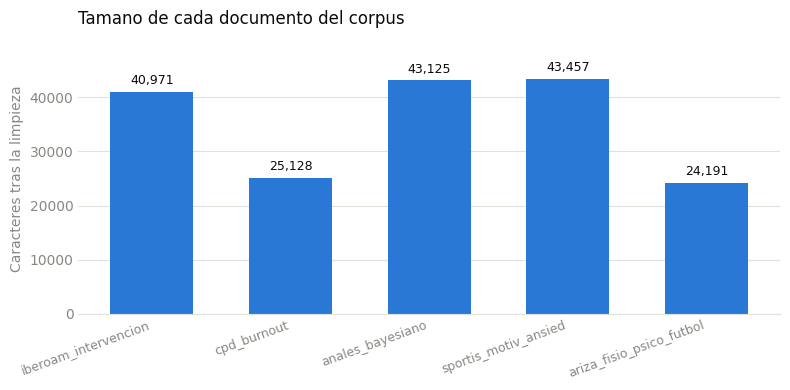

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar([d["id"] for d in documentos], longitudes, color=C_AZUL, width=0.6)
for i, v in enumerate(longitudes):
    ax.text(i, v + max(longitudes) * 0.02, f"{v:,}", ha="center", va="bottom",
            color=C_TINTA, fontsize=9)

ax.set_ylabel("Caracteres tras la limpieza", color=C_MUTED, fontsize=10)
ax.set_title("Tamano de cada documento del corpus", color=C_TINTA,
             fontsize=12, loc="left", pad=14)
ax.set_ylim(0, max(longitudes) * 1.15)

ax.grid(axis="y", color=C_GRILLA, linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(C_GRILLA)
ax.tick_params(colors=C_MUTED, length=0)
plt.xticks(rotation=20, ha="right", fontsize=9)

plt.tight_layout()
plt.show()

## 1.6 Las dos estrategias de chunking

**Estrategia A — Fixed-size.** Corta cada 800 caracteres con 100 de solapamiento, sin mirar el
contenido. El solapamiento existe para que una idea que cae justo en el borde aparezca completa
en alguno de los dos chunks.

**Estrategia B — Paragraph-aware.** Acumula párrafos completos hasta acercarse al límite de 800
caracteres y nunca parte un párrafo al medio. Cuando un párrafo por sí solo supera el límite
—pasa con los bloques de Resultados— lo divide por oraciones, que es el punto de corte menos malo.

Una consecuencia de esa regla: si una **oración suelta** ya excede los 800 caracteres, el chunk
sale más largo que el límite, porque partirla sería cortar al medio de una frase. En este corpus
el chunk más largo queda en unos 1.150 caracteres — sigue holgadamente por debajo del límite del
embedder, así que no se pierde nada.

**Sobre el tamaño elegido.** El embedder acepta hasta 512 tokens. En español, 800 caracteres son
unos 200-250 tokens, así que estamos con margen cómodo: ningún chunk se va a truncar. Ese es el
techo que hay que respetar — un chunk que excede el límite del modelo pierde su cola en silencio,
sin ningún aviso.

La hipótesis a contrastar en la Fase 3: en un corpus de papers, donde el párrafo es una unidad
semántica fuerte (el de Participantes tiene el `n` y las edades juntos, el de Instrumentos
describe una escala completa), la estrategia B debería recuperar mejor.

In [10]:
def chunk_fixed(texto, size, overlap):
    """Estrategia A: ventana fija de caracteres con solapamiento."""
    chunks, i, paso = [], 0, size - overlap
    while i < len(texto):
        fragmento = texto[i:i + size].strip()
        if len(fragmento) > 50:
            chunks.append(fragmento)
        i += paso
    return chunks


def chunk_paragraph(texto, max_size, min_size):
    """Estrategia B: agrupa parrafos completos sin partirlos."""
    parrafos = [p.strip() for p in texto.split("\n\n") if p.strip()]
    chunks, buffer = [], ""

    for p in parrafos:
        if len(p) > max_size:
            if buffer:
                chunks.append(buffer)
                buffer = ""
            oraciones = re.split(r"(?<=[.!?])\s+", p)     # parrafo gigante: cortar por oracion
            sub = ""
            for o in oraciones:
                if sub and len(sub) + len(o) + 1 > max_size:
                    chunks.append(sub)
                    sub = o
                else:
                    sub = (sub + " " + o).strip()
            buffer = sub
        elif not buffer:
            buffer = p
        elif len(buffer) + len(p) + 2 <= max_size:
            buffer = buffer + "\n\n" + p
        else:
            chunks.append(buffer)
            buffer = p

    if buffer:
        chunks.append(buffer)
    return [c for c in chunks if len(c) >= min_size]


def construir_chunks(docs, estrategia):
    """Arma la lista de chunks conservando la trazabilidad al documento fuente."""
    salida = []
    for doc in docs:
        piezas = (chunk_fixed(doc["texto"], CONFIG["fixed_size"], CONFIG["fixed_overlap"])
                  if estrategia == "fixed"
                  else chunk_paragraph(doc["texto"], CONFIG["par_max"], CONFIG["par_min"]))
        for n, texto in enumerate(piezas):
            salida.append({
                "chunk_id":   f"{doc['id']}__{estrategia}__{n}",
                "texto":      texto,
                "doc_id":     doc["id"],        # <- esto es lo que mide hit@k
                "doc_titulo": doc["titulo"],
                "eje":        doc["eje"],
                "pos":        n,
            })
    return salida


chunks_fixed = construir_chunks(documentos, "fixed")
chunks_par   = construir_chunks(documentos, "paragraph")

resumen = []
for etiqueta, cs in [("A - fixed-size", chunks_fixed), ("B - paragraph-aware", chunks_par)]:
    largos = [len(c["texto"]) for c in cs]
    resumen.append({"estrategia": etiqueta, "chunks": len(cs),
                    "largo medio": int(np.mean(largos)), "desvio": int(np.std(largos)),
                    "min": min(largos), "max": max(largos)})
pd.DataFrame(resumen).set_index("estrategia")

,chunks,largo medio,desvio,min,max
estrategia,,,,,
A - fixed-size,255,791,64,57,800
B - paragraph-aware,294,595,152,200,1144


### Discusión obligatoria: ¿qué diferencia se ve?

In [11]:
def mostrar_chunks(chunks, etiqueta, doc_id, cuantos=3):
    print("#" * 100)
    print(f"# {etiqueta}  —  {doc_id}")
    print("#" * 100)
    for c in [c for c in chunks if c["doc_id"] == doc_id][3:3 + cuantos]:
        print(f"\n--- {c['chunk_id']}  ({len(c['texto'])} chars) ---")
        print(textwrap.fill(c["texto"], 100))
    print()

doc_muestra = documentos[0]["id"]
mostrar_chunks(chunks_fixed, "ESTRATEGIA A — FIXED-SIZE", doc_muestra)
mostrar_chunks(chunks_par,   "ESTRATEGIA B — PARAGRAPH-AWARE", doc_muestra)

####################################################################################################
# ESTRATEGIA A — FIXED-SIZE  —  iberoam_intervencion
####################################################################################################

--- iberoam_intervencion__fixed__3  (800 chars) ---
e habilidades psicológicas para deportistas jóvenes; se realizó durante 12 semanas, de forma
colectiva e individual. Los resultados indican una buena valoración de la intervención y una alta
satisfacción con la misma; el 100% de los participantes indicó su deseo de continuar con el trabajo
psicológico la siguiente temporada. Además, los jugadores con mayor pasión por el fútbol demostraron
tener una mayor intención de práctica futura, de competición futura y de permanencia en el club.
PALABRAS CLAVE: Entrenamiento psicológico, jóvenes futbolistas, satisfacción, intención futura.
IMPLEMENTATION OF A PSYCHOLOGICAL INTERVENTION IN JUNIOR CATEGORIES OF  PRACTICE  KEYWORDS:
Psychological t

**Observaciones** _(completar leyendo la salida de arriba; abajo, qué mirar)_

- **¿Dónde corta cada una?** Fijate si los chunks de A empiezan o terminan a mitad de frase, y si
  los de B arrancan al inicio de un párrafo.
- **¿Se parte alguna idea en dos?** El caso típico: un chunk dice *"participaron 12 jugadores"* y
  el rango de edades quedó en el siguiente. Si pasa, es exactamente el fallo que después aparece
  en el `hit@k`.
- **¿Qué pasa con la variabilidad?** La tabla muestra el desvío estándar: A es uniforme por
  construcción, B es irregular porque sigue al texto. Un chunk muy corto le da poco contexto al
  embedder; uno muy largo diluye el tema principal.
- **Conclusión provisoria:** ¿cuál parece más prometedora para este corpus, y por qué?

---

# Fase 2 — Embeddings e indexación

Cada chunk se convierte en un vector denso que captura su significado, y esos vectores van a un
índice FAISS que permite buscar por similitud.

**El modelo:** `paraphrase-multilingual-mpnet-base-v2`. Es multilingüe y está entrenado
específicamente para que dos textos que dicen lo mismo con palabras distintas queden cerca en el
espacio vectorial. Eso es justo lo que necesitamos: el chico va a preguntar *"¿cómo hago para no
ponerme nervioso antes de un partido?"* y en el corpus dice *"técnicas de control de la
activación precompetitiva"*. Cero palabras en común, mismo significado.

**Por qué normalizamos los vectores.** FAISS tiene varios tipos de índice. `IndexFlatIP` calcula
el **producto interno** entre vectores. Si los vectores están normalizados (norma 1), el producto
interno **es** la similitud coseno — que es la métrica correcta para comparar embeddings, porque
mide el ángulo entre vectores e ignora su magnitud. Normalizar y usar `IndexFlatIP` es entonces
la forma estándar de hacer búsqueda por coseno en FAISS.

El `Flat` significa que compara contra todos los vectores, sin aproximar. Es el más lento, pero
con unos pocos miles de chunks es instantáneo y nos da el resultado exacto — no queremos que un
índice aproximado nos ensucie la medición del `hit@k`.

**Construimos dos índices**, uno por estrategia de chunking, para poder compararlos en la Fase 3.

In [12]:
from sentence_transformers import SentenceTransformer
import faiss

print("Cargando el modelo de embeddings...")
embedder = SentenceTransformer(CONFIG["embedder"])
print(f"Listo. Dimension de los vectores: {embedder.get_sentence_embedding_dimension()}")

Cargando el modelo de embeddings...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Listo. Dimension de los vectores: 768


In [13]:
def construir_indice(chunks, modelo):
    """Devuelve un indice FAISS de similitud coseno sobre los chunks dados."""
    textos = [c["texto"] for c in chunks]
    emb = modelo.encode(
        textos,
        batch_size=32,
        convert_to_numpy=True,
        normalize_embeddings=True,     # <- normalizar: producto interno == coseno
        show_progress_bar=True,
    ).astype("float32")

    indice = faiss.IndexFlatIP(emb.shape[1])
    indice.add(emb)
    return indice, emb


def buscar(query, k, indice, chunks, modelo=None):
    """Devuelve los k chunks mas similares a la consulta, con su score."""
    modelo = modelo or embedder
    q = modelo.encode([query], convert_to_numpy=True,
                      normalize_embeddings=True).astype("float32")
    scores, posiciones = indice.search(q, k)
    resultados = []
    for score, pos in zip(scores[0], posiciones[0]):
        if pos == -1:
            continue
        r = dict(chunks[pos])
        r["score"] = float(score)
        resultados.append(r)
    return resultados


print("Indexando estrategia A (fixed-size)...")
indice_fixed, _ = construir_indice(chunks_fixed, embedder)

print("Indexando estrategia B (paragraph-aware)...")
indice_par, _ = construir_indice(chunks_par, embedder)

print(f"\nIndice A: {indice_fixed.ntotal} vectores")
print(f"Indice B: {indice_par.ntotal} vectores")

Indexando estrategia A (fixed-size)...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Indexando estrategia B (paragraph-aware)...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Indice A: 255 vectores
Indice B: 294 vectores


### Probamos que el retrieval funcione

Una consulta escrita como la escribiría un jugador, no como está en el paper. Si el embedder
está haciendo su trabajo, debería traer fragmentos relevantes igual.

In [14]:
consulta = "me pongo muy nervioso antes de los partidos, ¿que puedo hacer?"

for etiqueta, indice, chunks in [("A - fixed-size", indice_fixed, chunks_fixed),
                                 ("B - paragraph-aware", indice_par, chunks_par)]:
    print("=" * 100)
    print(f"ESTRATEGIA {etiqueta}  —  consulta: {consulta!r}")
    print("=" * 100)
    for i, r in enumerate(buscar(consulta, 3, indice, chunks), 1):
        print(f"\n[{i}] score {r['score']:.3f}  |  fuente: {r['doc_id']}")
        print(textwrap.fill(r["texto"][:400], 100))
    print()

ESTRATEGIA A - fixed-size  —  consulta: 'me pongo muy nervioso antes de los partidos, ¿que puedo hacer?'

[1] score 0.472  |  fuente: sportis_motiv_ansied
ntinuidad en la práctica del deporte (Prieto y Ramírez, 2021; Iglesias et al., 2019).  Uno de los
factores psicológicos más estudiados en el ámbito deportivo es la ansiedad competitiva, definida
como una respuesta emocional ante la percepción de amenaza en situaciones de competición (Cox et
al., 2010). Esta ansiedad puede manifestarse a través de síntomas cognitivos (como preocupación o
pensamient

[2] score 0.421  |  fuente: sportis_motiv_ansied
s jóvenes deportistas (Lorenzón et al., 2022; Bueno et al., 2023) La asociación positiva entre la
ansiedad somática y la desconcentración con las dimensiones de la ansiedad general confirma que los
estados emocionales negativos pueden impactar de manera significativa en el rendimiento deportivo
(Nuñez y García- Mas, 2017; Riquelme et al., 2020; Arroyo et al., 2022). Este hallazgo refuerza la

---

# Fase 3 — Evaluación del retrieval

Hasta acá el retrieval "parece" andar. Esta fase lo mide.

## 3.1 El set de evaluación

Diez preguntas, cada una anotada con el documento donde está la respuesta. El criterio para
formularlas: **respuesta específica, corta y contenida en un único documento.** Si una pregunta
se puede responder desde tres artículos distintos, no sirve para medir si el retrieval encontró
"el" documento correcto.

Las preguntas se reparten en tres tipos a propósito, porque esperamos que se comporten distinto:

- **Factuales de estudio** (`n` muestral, instrumento, país): muy específicas, el retrieval
  debería acertarlas y el LLM sin RAG no tiene forma de saberlas.
- **De protocolo** (cuántas sesiones, qué técnicas): las útiles para el jugador.
- **De hallazgo** (qué relación se encontró): más conceptuales, y por eso las candidatas a que
  el retrieval se confunda de documento — varios papers hablan de motivación y ansiedad.

Las diez preguntas están **verificadas contra el texto real** de los cinco documentos: cada
`respuesta_esperada` se leyó en el artículo anotado en `doc_id`. Eso importa porque el `hit@k`
sólo mide algo si la anotación es correcta.

Un cuidado extra al redactarlas: los cinco artículos reportan un `n` muestral, así que una
pregunta como *"¿cuántos jugadores participaron?"* sería ambigua y tendría respuesta en todos. Por
eso cada pregunta está anclada a algo que aparece en **un solo** artículo.

**Dos preguntas por documento**, diez en total. El corpus tiene dos estudios de intervención
distintos (Navarrón con 12 jugadores de un club local durante 12 semanas; Olmedilla con 22 de un
club profesional durante cinco meses), así que las preguntas sobre ellos están redactadas con el
dato que los distingue. Sin ese cuidado, *"¿cuánto duró la intervención?"* tendría dos respuestas
correctas en documentos distintos y el `hit@k` castigaría al retrieval por acertar.

In [16]:
# ---------------------------------------------------------------------------
# SET DE EVALUACION - 10 preguntas anotadas y verificadas contra el texto.
#   doc_id -> documento donde esta la respuesta
#   tipo   -> factual | protocolo | hallazgo
# ---------------------------------------------------------------------------
PREGUNTAS = [
    # --- Arroyo del Bosque et al. (2025), Sportis --------------------------
    {"id": "P01", "tipo": "factual",
     "pregunta": "¿Cuántos futbolistas participaron en el estudio de categorías infantiles y cómo se repartían entre varones y mujeres?",
     "doc_id": "sportis_motiv_ansied",
     "respuesta_esperada": "127 futbolistas: 94 varones y 33 mujeres, de 10 a 13 años (media 11,5)"},

    {"id": "P02", "tipo": "hallazgo",
     "pregunta": "En el fútbol formativo de categorías infantiles, ¿qué orientación motivacional predominó, la de tarea o la de ego?",
     "doc_id": "sportis_motiv_ansied",
     "respuesta_esperada": "Predominó la orientación hacia la tarea por sobre la orientación al ego"},

    # --- Navarron et al. (2017), Rev. Iberoamericana -----------------------
    # Ojo: hay otro estudio de intervencion en el corpus (Olmedilla). Estas dos
    # preguntas se anclan en datos que solo aparecen en este.
    {"id": "P03", "tipo": "protocolo",
     "pregunta": "¿Cuántas semanas duró la intervención psicológica realizada con 12 jugadores de un club de fútbol local, y en qué formato se aplicó?",
     "doc_id": "iberoam_intervencion",
     "respuesta_esperada": "12 semanas, en formato colectivo e individual, integrada al entrenamiento deportivo general"},

    {"id": "P04", "tipo": "hallazgo",
     "pregunta": "¿Qué porcentaje de participantes indicó que deseaba continuar con el trabajo psicológico la temporada siguiente?",
     "doc_id": "iberoam_intervencion",
     "respuesta_esperada": "El 100% de los participantes"},

    # --- Leon Ariza, Sanchez Jimenez y Ramirez Villada (2011), Cuerpo Cultura y Movimiento --
    # Es una revision, no un estudio propio: cita varias muestras distintas dentro del MISMO
    # documento (219 jugadores costarricenses, 40 chilenos, 399 italianos). Por eso P05 se
    # ancla explicitamente "al estudio costarricense" y no pregunta el n de forma generica.
    {"id": "P05", "tipo": "factual",
     "pregunta": "Segun el estudio costarricense citado en la revision sobre demandas fisiologicas y psicologicas en el futbol, ¿a cuantos jugadores se les midio el consumo maximo de oxigeno y que valor promedio obtuvieron?",
     "doc_id": "ariza_fisio_psico_futbol",
     "respuesta_esperada": "219 jugadores; VO2 max. promedio de 57,71 +/- 8,8 ml O2/kg/min (Sanchez y Salas, 2009)"},

    {"id": "P06", "tipo": "hallazgo",
     "pregunta": "¿Que relacion se ha encontrado entre la economia de carrera de un futbolista profesional y la de uno aficionado?",
     "doc_id": "ariza_fisio_psico_futbol",
     "respuesta_esperada": "Puede haber hasta un 20% de diferencia a favor del profesional, equivalente a unos 5 ml/kg/min menos de consumo de oxigeno, casi diez latidos menos, o cerca de 1500 metros menos de esfuerzo por partido"},

    # --- De Francisco et al. (2009), Cuadernos -----------------------------
    {"id": "P07", "tipo": "factual",
     "pregunta": "¿Qué tres subescalas componen el Athlete Burnout Questionnaire?",
     "doc_id": "cpd_burnout",
     "respuesta_esperada": "Agotamiento físico/emocional, reducida sensación de logro y devaluación del deporte practicado"},

    {"id": "P08", "tipo": "protocolo",
     "pregunta": "¿A cuántos jóvenes futbolistas se aplicó la versión española del Athlete Burnout Questionnaire y de qué edades?",
     "doc_id": "cpd_burnout",
     "respuesta_esperada": "A 140 jóvenes futbolistas de entre 16 y 19 años (más un estudio piloto previo con 15)"},

    # --- Garcia-Mas et al. (2015), Anales de Psicologia --------------------
    {"id": "P09", "tipo": "factual",
     "pregunta": "En el análisis bayesiano de la motivación y la ansiedad, ¿qué instrumentos se administraron y a cuántos jugadores?",
     "doc_id": "anales_bayesiano",
     "respuesta_esperada": "PMCSQ, TEOSQ, BRSQ, CDED y SAS-2, a 270 jugadores de fútbol, balonmano y baloncesto (edad media 14,67)"},

    {"id": "P10", "tipo": "hallazgo",
     "pregunta": "¿Cuántos ítems tiene el cuestionario de clima motivacional percibido PMCSQ y qué subescalas incluye?",
     "doc_id": "anales_bayesiano",
     "respuesta_esperada": "10 ítems y dos subescalas: clima motivacional percibido de ego y clima motivacional percibido de tarea"},
]

# Chequeo de consistencia: que los doc_id existan entre los documentos cargados
ids_disponibles = {d["id"] for d in documentos}
huerfanas = [p["id"] for p in PREGUNTAS if p["doc_id"] not in ids_disponibles]
if huerfanas:
    print(f"ATENCION: preguntas que apuntan a documentos no cargados: {huerfanas}")
else:
    print(f"OK: las {len(PREGUNTAS)} preguntas apuntan a documentos disponibles.")

cobertura = Counter(p["doc_id"] for p in PREGUNTAS)
print("Preguntas por documento:", dict(cobertura))
sin_preguntas = ids_disponibles - set(cobertura)
if sin_preguntas:
    print("Documentos sin ninguna pregunta:", sin_preguntas)

pd.DataFrame(PREGUNTAS)[["id", "tipo", "doc_id", "pregunta"]]

OK: las 10 preguntas apuntan a documentos disponibles.
Preguntas por documento: {'sportis_motiv_ansied': 2, 'iberoam_intervencion': 2, 'ariza_fisio_psico_futbol': 2, 'cpd_burnout': 2, 'anales_bayesiano': 2}


,id,tipo,doc_id,pregunta
0,P01,factual,sportis_motiv_ansied,¿Cuántos futbolistas participaron en el estudio de categorías infantiles y cómo se rep...
1,P02,hallazgo,sportis_motiv_ansied,"En el fútbol formativo de categorías infantiles, ¿qué orientación motivacional predomi..."
2,P03,protocolo,iberoam_intervencion,¿Cuántas semanas duró la intervención psicológica realizada con 12 jugadores de un clu...
3,P04,hallazgo,iberoam_intervencion,¿Qué porcentaje de participantes indicó que deseaba continuar con el trabajo psicológi...
4,P05,factual,ariza_fisio_psico_futbol,Segun el estudio costarricense citado en la revision sobre demandas fisiologicas y psi...
5,P06,hallazgo,ariza_fisio_psico_futbol,¿Que relacion se ha encontrado entre la economia de carrera de un futbolista profesion...
6,P07,factual,cpd_burnout,¿Qué tres subescalas componen el Athlete Burnout Questionnaire?
7,P08,protocolo,cpd_burnout,¿A cuántos jóvenes futbolistas se aplicó la versión española del Athlete Burnout Quest...
8,P09,factual,anales_bayesiano,"En el análisis bayesiano de la motivación y la ansiedad, ¿qué instrumentos se administ..."
9,P10,hallazgo,anales_bayesiano,¿Cuántos ítems tiene el cuestionario de clima motivacional percibido PMCSQ y qué subes...


### Herramienta de verificación de la anotación

Para cada pregunta muestra qué documentos devuelve el retrieval. Sirve para chequear si la
anotación es correcta: si una pregunta trae consistentemente chunks de otro documento, o bien la
anotación está mal, o bien la pregunta no es lo bastante específica y hay que reformularla.

In [17]:
filas = []
for p in PREGUNTAS:
    encontrados = buscar(p["pregunta"], 5, indice_par, chunks_par)
    fuentes = [r["doc_id"] for r in encontrados]
    filas.append({
        "id": p["id"],
        "anotado": p["doc_id"],
        "top-5 recuperado": " > ".join(dict.fromkeys(fuentes)),
        "acierta": "sí" if p["doc_id"] in fuentes else "NO",
    })
pd.DataFrame(filas)

,id,anotado,top-5 recuperado,acierta
0,P01,sportis_motiv_ansied,sportis_motiv_ansied > anales_bayesiano > cpd_burnout > iberoam_intervencion,sí
1,P02,sportis_motiv_ansied,sportis_motiv_ansied,sí
2,P03,iberoam_intervencion,iberoam_intervencion > anales_bayesiano,sí
3,P04,iberoam_intervencion,iberoam_intervencion,sí
4,P05,ariza_fisio_psico_futbol,ariza_fisio_psico_futbol,sí
5,P06,ariza_fisio_psico_futbol,ariza_fisio_psico_futbol > sportis_motiv_ansied > iberoam_intervencion,sí
6,P07,cpd_burnout,cpd_burnout,sí
7,P08,cpd_burnout,anales_bayesiano > cpd_burnout > sportis_motiv_ansied > iberoam_intervencion,sí
8,P09,anales_bayesiano,anales_bayesiano > sportis_motiv_ansied,sí
9,P10,anales_bayesiano,anales_bayesiano,sí


## 3.2 La métrica `hit@k`

Una pregunta cuenta como *hit* en `k` si **al menos uno** de los `k` chunks recuperados proviene
del documento correcto. `hit@k` es la proporción de preguntas que son hit.

Es una métrica deliberadamente permisiva: no exige que el chunk correcto salga primero, sólo que
aparezca entre los primeros `k`. Eso tiene sentido en RAG, porque al LLM le pasamos varios chunks
como contexto: alcanza con que el bueno esté ahí.

Por eso mismo `hit@1` es el número más exigente y el más informativo sobre la calidad real del
ranking.

In [18]:
def hit_at_k(preguntas, indice, chunks, k):
    aciertos = 0
    for p in preguntas:
        recuperados = buscar(p["pregunta"], k, indice, chunks)
        if any(r["doc_id"] == p["doc_id"] for r in recuperados):
            aciertos += 1
    return aciertos / len(preguntas)


resultados = []
for etiqueta, indice, chunks in [("A - fixed-size", indice_fixed, chunks_fixed),
                                 ("B - paragraph-aware", indice_par, chunks_par)]:
    fila = {"estrategia": etiqueta}
    for k in CONFIG["k_values"]:
        fila[f"hit@{k}"] = hit_at_k(PREGUNTAS, indice, chunks, k)
    resultados.append(fila)

df_hits = pd.DataFrame(resultados).set_index("estrategia")
print("Resultados del retrieval sobre las 10 preguntas:\n")
df_hits.style.format("{:.0%}")

Resultados del retrieval sobre las 10 preguntas:



,hit@1,hit@3,hit@5
estrategia,,,
A - fixed-size,70%,100%,100%
B - paragraph-aware,90%,100%,100%


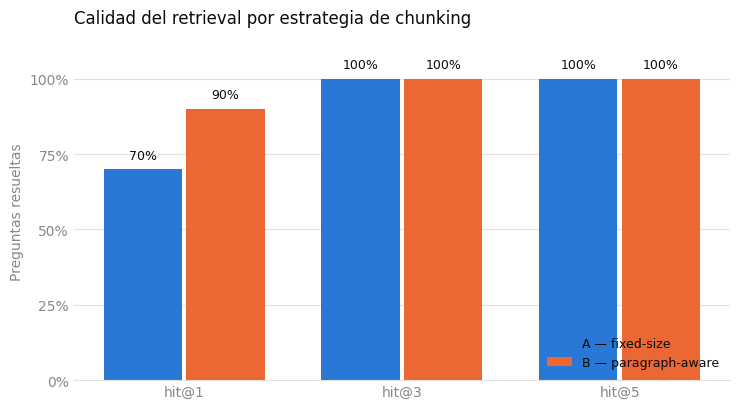

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

ks = CONFIG["k_values"]
x = np.arange(len(ks))
ancho = 0.36

vals_a = [df_hits.loc["A - fixed-size", f"hit@{k}"] for k in ks]
vals_b = [df_hits.loc["B - paragraph-aware", f"hit@{k}"] for k in ks]

b1 = ax.bar(x - ancho/2 - 0.01, vals_a, ancho, label="A — fixed-size", color=C_AZUL)
b2 = ax.bar(x + ancho/2 + 0.01, vals_b, ancho, label="B — paragraph-aware", color=C_NARANJA)

# etiqueta directa sobre cada barra: el valor exacto sin tener que leer el eje
for barras in (b1, b2):
    for b in barras:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.025,
                f"{b.get_height():.0%}", ha="center", va="bottom",
                color=C_TINTA, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"hit@{k}" for k in ks], color=C_TINTA, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.set_ylabel("Preguntas resueltas", color=C_MUTED, fontsize=10)
ax.set_title("Calidad del retrieval por estrategia de chunking",
             color=C_TINTA, fontsize=12, loc="left", pad=14)

ax.grid(axis="y", color=C_GRILLA, linewidth=0.8)
ax.set_axisbelow(True)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(C_GRILLA)
ax.tick_params(colors=C_MUTED, length=0)
ax.legend(frameon=False, loc="lower right", fontsize=9, labelcolor=C_TINTA)

plt.tight_layout()
plt.show()

### Desglose por tipo de pregunta

El promedio esconde el patrón. Esto muestra dónde falla cada estrategia.

In [20]:
filas = []
for tipo in ["factual", "protocolo", "hallazgo"]:
    grupo = [p for p in PREGUNTAS if p["tipo"] == tipo]
    if not grupo:
        continue
    filas.append({
        "tipo": tipo,
        "n": len(grupo),
        "A hit@3": hit_at_k(grupo, indice_fixed, chunks_fixed, 3),
        "B hit@3": hit_at_k(grupo, indice_par,   chunks_par,   3),
    })
pd.DataFrame(filas).set_index("tipo").style.format({"A hit@3": "{:.0%}", "B hit@3": "{:.0%}"})

,n,A hit@3,B hit@3
tipo,,,
factual,4,100%,100%
protocolo,2,100%,100%
hallazgo,4,100%,100%


### Discusión obligatoria

_(completar con los números reales una vez ejecutado)_

- **¿Qué estrategia ganó y en qué `k`?** Puede pasar que empaten en `hit@5` y se diferencien en
  `hit@1`: eso significa que las dos encuentran el documento, pero una lo rankea mejor.
- **¿Cuánto mejora paragraph-aware sobre fixed?** Con 10 preguntas, una diferencia de una sola
  pregunta son 10 puntos porcentuales. Conviene ser honestos sobre eso: el set es chico y una
  diferencia de un punto no es evidencia fuerte. Lo que sí vale es mirar si la diferencia es
  consistente a través de los tres valores de `k`.
- **¿Qué dice el desglose por tipo?** La hipótesis era que las preguntas de tipo *hallazgo* son
  las más difíciles, porque varios documentos comparten el vocabulario conceptual. ¿Se cumplió?
- **¿Qué preguntas fallaron en las dos estrategias?** Esas son las interesantes: el problema no
  está en el chunking sino en la pregunta o en el corpus.

  RESPUESTA:  	hit@1	hit@3	hit@5
estrategia
A - fixed-size	70%	100%	100%
B - paragraph-aware	90%	100%	100%
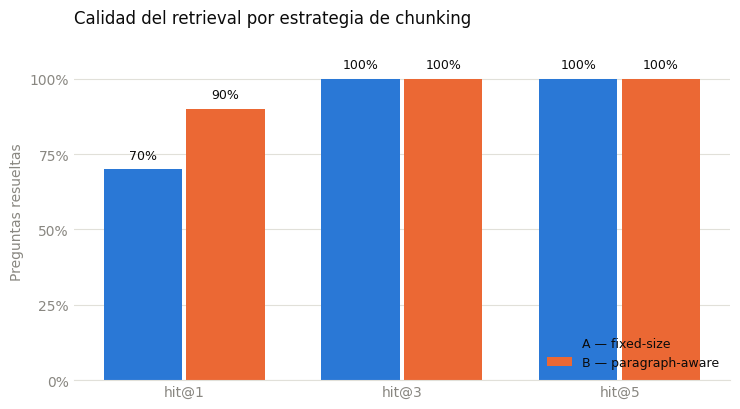

---

# Fase 4 — Generación con LLM

Acá se arma el asistente completo y se responde la pregunta central del TP: **¿cuánto aporta
realmente el RAG?**

Comparamos dos modos sobre las mismas 10 preguntas:

- `responder_con_rag`: recupera los chunks más relevantes y se los pasa al modelo como contexto,
  con instrucciones estrictas de responder **sólo** con eso.
- `responder_sin_rag`: le hace la pregunta pelada al modelo.

El modelo es `Qwen2.5-1.5B-Instruct`: chico, entra cómodo en la T4 gratuita de Colab y maneja
español. Que sea chico es una ventaja para este experimento — hace más visible la diferencia
entre tener y no tener contexto.

**Generación determinística.** Usamos `do_sample=False`, o sea el modelo siempre elige el token
más probable. Sin esto, dos corridas darían respuestas distintas y la anotación humana no sería
reproducible: alguien que vuelva a correr el notebook vería respuestas que no coinciden con
nuestra tabla.

In [21]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
if dispositivo == "cpu":
    print("ATENCION: no hay GPU. Esta fase va a ser MUY lenta.")
    print("Entorno de ejecucion -> Cambiar tipo de entorno -> T4 GPU\n")

print(f"Cargando {CONFIG['llm']} en {dispositivo}...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["llm"])
modelo_llm = AutoModelForCausalLM.from_pretrained(
    CONFIG["llm"],
    torch_dtype=torch.float16 if dispositivo == "cuda" else torch.float32,
    device_map="auto",
)
modelo_llm.eval()
print("Modelo cargado.")

Cargando Qwen/Qwen2.5-1.5B-Instruct en cuda...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modelo cargado.


## 4.1 El prompt de grounding

Este prompt es el corazón del sistema. Tiene que lograr algo que a los modelos les cuesta:
**admitir que no saben**.

Cuatro decisiones de redacción, cada una contra un modo de fallo concreto:

1. **"Usá únicamente la información del CONTEXTO"** — sin esto, el modelo mezcla el contexto con
   lo que cree recordar de su pre-entrenamiento, y ahí es donde se cuelan las alucinaciones más
   difíciles de detectar: las que suenan coherentes con el resto de la respuesta.
2. **La frase exacta de rechazo** — le damos la cadena literal *"No tengo información
   suficiente"*. Si le dejamos elegir las palabras, va a decir algo como *"no estoy del todo
   seguro, pero probablemente..."* y seguir inventando igual.
3. **"Respondé en español"** — Qwen es un modelo chino y ante preguntas técnicas tiende a
   responder en inglés.
4. **El tono** — el destinatario es un jugador juvenil, no un investigador. Pedimos lenguaje
   claro, aunque el contexto esté escrito en registro académico. Esta instrucción es la que
   convierte un buscador de papers en un asistente.

In [22]:
PROMPT_SISTEMA_RAG = """Sos un asistente que ayuda a jóvenes futbolistas con su preparación psicológica.

Reglas que tenés que cumplir siempre:
1. Respondé ÚNICAMENTE con información que esté en el CONTEXTO que te doy.
2. Si el contexto no alcanza para responder, respondé exactamente: "No tengo información suficiente".
3. No inventes datos, cifras, nombres de autores ni fechas que no estén en el contexto.
4. Respondé en español, en lenguaje claro y directo, como si le hablaras a un jugador juvenil.
5. Sé breve: tres o cuatro oraciones alcanzan."""

PROMPT_SISTEMA_SIN_RAG = """Sos un asistente que ayuda a jóvenes futbolistas con su preparación psicológica.
Respondé en español, de forma clara y breve."""


def generar(mensajes, max_tokens=None):
    texto = tokenizer.apply_chat_template(
        mensajes, tokenize=False, add_generation_prompt=True)
    entradas = tokenizer(texto, return_tensors="pt").to(modelo_llm.device)
    with torch.no_grad():
        salida = modelo_llm.generate(
            **entradas,
            max_new_tokens=max_tokens or CONFIG["max_tokens"],
            do_sample=False,                       # determinista y reproducible
            pad_token_id=tokenizer.eos_token_id,
        )
    nuevos = salida[0][entradas["input_ids"].shape[1]:]
    return tokenizer.decode(nuevos, skip_special_tokens=True).strip()


def responder_con_rag(pregunta, indice=None, chunks=None, k=None, devolver_fuentes=False):
    indice = indice if indice is not None else indice_par
    chunks = chunks if chunks is not None else chunks_par
    k = k or CONFIG["k_rag"]

    recuperados = buscar(pregunta, k, indice, chunks)
    contexto = "\n\n---\n\n".join(
        f"[Fuente: {r['doc_titulo']}]\n{r['texto']}" for r in recuperados)

    mensajes = [
        {"role": "system", "content": PROMPT_SISTEMA_RAG},
        {"role": "user",   "content": f"CONTEXTO:\n{contexto}\n\nPREGUNTA: {pregunta}"},
    ]
    respuesta = generar(mensajes)
    if devolver_fuentes:
        return respuesta, recuperados
    return respuesta


def responder_sin_rag(pregunta):
    mensajes = [
        {"role": "system", "content": PROMPT_SISTEMA_SIN_RAG},
        {"role": "user",   "content": pregunta},
    ]
    return generar(mensajes)


print("Funciones listas.")

Funciones listas.


### Prueba rápida antes de la corrida completa

Una pregunta de control con respuesta que **no está en el corpus**. Si el prompt de grounding
funciona, el modo RAG debería contestar *"No tengo información suficiente"* en vez de inventar.
Es el test más importante del sistema: un asistente que inventa es peor que no tener asistente.

In [23]:
control = "¿Cuánto salió el pase de Lionel Messi al Inter Miami?"

print("PREGUNTA DE CONTROL (fuera del corpus):", control)
print("\n--- CON RAG ---")
print(textwrap.fill(responder_con_rag(control), 100))
print("\n--- SIN RAG ---")
print(textwrap.fill(responder_sin_rag(control), 100))

PREGUNTA DE CONTROL (fuera del corpus): ¿Cuánto salió el pase de Lionel Messi al Inter Miami?

--- CON RAG ---
Lo siento, pero no puedo proporcionar esa información ya que no existe ningún registro público sobre
el pase específico de Lionel Messi al Inter Miami. Los datos de transferencias y estadísticas
deportivas suelen ser confidenciales y protegidos por derechos de autor. Te recomendaría buscar en
fuentes oficiales de noticias deportivas o sitios web especializados en transfers para obtener
información precisa y actualizada.

--- SIN RAG ---
Lionel Messi no firmó por el Inter Miami. Fue la vicepresidenta ejecutiva del club, Laura Pons,
quien anunció oficialmente la llegada del astro argentino a los Estados Unidos en diciembre de 2021.


## 4.2 Corrida sobre el set de evaluación

Generamos las 20 respuestas (10 preguntas × 2 modos). En una T4 tarda unos minutos.

In [24]:
respuestas = []
for i, p in enumerate(PREGUNTAS, 1):
    print(f"[{i}/{len(PREGUNTAS)}] {p['id']}...", end=" ", flush=True)
    con_rag, fuentes = responder_con_rag(p["pregunta"], devolver_fuentes=True)
    sin_rag = responder_sin_rag(p["pregunta"])
    respuestas.append({
        "id": p["id"],
        "tipo": p["tipo"],
        "pregunta": p["pregunta"],
        "doc_esperado": p["doc_id"],
        "doc_recuperado": " > ".join(dict.fromkeys(r["doc_id"] for r in fuentes)),
        "respuesta_esperada": p["respuesta_esperada"],
        "con_rag": con_rag,
        "sin_rag": sin_rag,
    })
    print("ok")

df_respuestas = pd.DataFrame(respuestas)
df_respuestas.to_csv("respuestas_generadas.csv", index=False)
print(f"\n{len(df_respuestas)} preguntas respondidas en ambos modos.")
print("Guardado en respuestas_generadas.csv")

[1/10] P01... ok
[2/10] P02... ok
[3/10] P03... ok
[4/10] P04... ok
[5/10] P05... ok
[6/10] P06... ok
[7/10] P07... ok
[8/10] P08... ok
[9/10] P09... ok
[10/10] P10... ok

10 preguntas respondidas en ambos modos.
Guardado en respuestas_generadas.csv


In [25]:
# Lectura completa de las 20 respuestas, para hacer la anotacion
for r in respuestas:
    print("=" * 100)
    print(f"{r['id']} [{r['tipo']}]  {r['pregunta']}")
    print(f"documento esperado: {r['doc_esperado']}  |  recuperado: {r['doc_recuperado']}")
    print(f"respuesta esperada: {r['respuesta_esperada']}")
    print("-" * 100)
    print("CON RAG:")
    print(textwrap.fill(r["con_rag"], 100, initial_indent="  ", subsequent_indent="  "))
    print("\nSIN RAG:")
    print(textwrap.fill(r["sin_rag"], 100, initial_indent="  ", subsequent_indent="  "))
    print()

P01 [factual]  ¿Cuántos futbolistas participaron en el estudio de categorías infantiles y cómo se repartían entre varones y mujeres?
documento esperado: sportis_motiv_ansied  |  recuperado: sportis_motiv_ansied > anales_bayesiano > cpd_burnout > iberoam_intervencion
respuesta esperada: 127 futbolistas: 94 varones y 33 mujeres, de 10 a 13 años (media 11,5)
----------------------------------------------------------------------------------------------------
CON RAG:
  En el estudio sobre categorías infantiles, participaron 127 futbolistas. Entre ellos:  - 33 fueron
  varones, - 94 eran mujeres.

SIN RAG:
  El estudio de categorías infantiles tuvo una participación significativa de futbolistas. Según los
  datos proporcionados:  - **Total de participantes**: 105 futbolistas - **Varones**: 73 futbolistas
  (69%) - **Mujeres**: 32 futbolistas (31%)  Estos números indican que la mayoría de los
  participantes eran hombres, aunque hay una representación decente de jugadoras femeninas en el
  e

## 4.3 Anotación humana

Cada una de las 20 respuestas se etiqueta con una de cuatro categorías:

| | Categoría | Criterio |
|---|---|---|
| **C** | Correcta | Responde lo esperado, exacto o muy cerca |
| **P** | Parcialmente correcta | Responde parte, omite información o agrega errores menores |
| **I** | Incorrecta | Responde otra cosa, **pero sin inventar datos** |
| **A** | Alucinación | Inventa datos falsos: fechas, nombres, cifras, hechos que no están en el corpus ni son ciertos |

**La distinción I vs A es la que importa** y es la que más se presta a confusión al anotar. La
regla práctica: preguntarse *"¿el modelo afirmó algo concreto y verificable que es falso?"*. Si
dijo "no sé" o se fue por las ramas sin afirmar nada, es **I**. Si dijo "el estudio incluyó 120
jugadores" y el número es inventado, es **A**. La segunda es mucho más grave para este proyecto:
un chico que lee una cifra inventada no tiene forma de detectarla.

Un caso que conviene acordar de antemano: **"No tengo información suficiente" cuando la
información sí estaba en el contexto** es una **I** (el modelo falló, pero no mintió). Es el
falso negativo del sistema RAG y vale la pena contarlo aparte en el análisis.

> ### ⚠️ Paso manual
>
> Completá el diccionario de abajo leyendo la salida de la celda anterior. Los valores arrancan
> en `None` justamente para que no se pueda "ejecutar todo" sin hacer este trabajo.
>
> **Sugerencia para el grupo:** que dos integrantes anoten por separado y después comparen. Donde
> no coinciden, casi siempre es una I vs A mal definida. Mencionarlo en el reporte suma.

In [26]:
# ---------------------------------------------------------------------------
# ANOTACION HUMANA - completar con "C", "P", "I" o "A"
# ---------------------------------------------------------------------------
ANOTACION = {
    # id      con_rag  sin_rag
    "P01":   {"con_rag": "A", "sin_rag":"A" },
    "P02":   {"con_rag": "I", "sin_rag":"P"},
    "P03":   {"con_rag": "C", "sin_rag": "A"},
    "P04":   {"con_rag": "C", "sin_rag": "I"},
    "P05":   {"con_rag": "A", "sin_rag": "I"},
    "P06":   {"con_rag": "I", "sin_rag": "I"},
    "P07":   {"con_rag": "C", "sin_rag": "P"},
    "P08":   {"con_rag": "A", "sin_rag": "I"},
    "P09":   {"con_rag": "I", "sin_rag": "A"},
    "P10":   {"con_rag": "C", "sin_rag": "I"},
}

faltantes = [pid for pid, v in ANOTACION.items()
             if v["con_rag"] is None or v["sin_rag"] is None]
if faltantes:
    print(f"Faltan anotar {len(faltantes)} preguntas: {', '.join(faltantes)}")
    print("La tabla C/P/I/A de la celda siguiente va a estar incompleta hasta que se completen.")
else:
    print("Anotacion completa.")

Anotacion completa.


In [27]:
CATEGORIAS = ["C", "P", "I", "A"]
NOMBRES = {"C": "Correcta", "P": "Parcial", "I": "Incorrecta", "A": "Alucinacion"}

def tabla_cpia(anotacion):
    filas = []
    for modo, etiqueta in [("con_rag", "CON RAG"), ("sin_rag", "SIN RAG")]:
        valores = [v[modo] for v in anotacion.values() if v[modo] is not None]
        total = len(valores) or 1
        fila = {"modo": etiqueta, "anotadas": len(valores)}
        for c in CATEGORIAS:
            fila[f"{c} — {NOMBRES[c]}"] = valores.count(c) / total
        filas.append(fila)
    return pd.DataFrame(filas).set_index("modo")

df_cpia = tabla_cpia(ANOTACION)
print("Tasas C/P/I/A sobre el set de evaluacion:\n")
df_cpia.style.format({c: "{:.0%}" for c in df_cpia.columns if c != "anotadas"})

Tasas C/P/I/A sobre el set de evaluacion:



,anotadas,C — Correcta,P — Parcial,I — Incorrecta,A — Alucinacion
modo,,,,,
CON RAG,10,40%,0%,30%,30%
SIN RAG,10,0%,20%,50%,30%


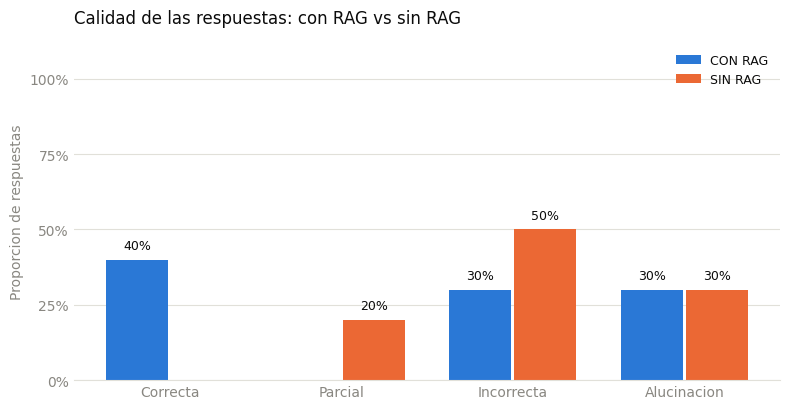

In [28]:
# Grafico comparativo. Se dibuja solo si hay anotacion cargada.
if not faltantes:
    fig, ax = plt.subplots(figsize=(8, 4.2))

    x = np.arange(len(CATEGORIAS))
    ancho = 0.36
    cols = [f"{c} — {NOMBRES[c]}" for c in CATEGORIAS]
    vals_rag = [df_cpia.loc["CON RAG", c] for c in cols]
    vals_sin = [df_cpia.loc["SIN RAG", c] for c in cols]

    b1 = ax.bar(x - ancho/2 - 0.01, vals_rag, ancho, label="CON RAG", color=C_AZUL)
    b2 = ax.bar(x + ancho/2 + 0.01, vals_sin, ancho, label="SIN RAG", color=C_NARANJA)

    for barras in (b1, b2):
        for b in barras:
            if b.get_height() > 0:
                ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.025,
                        f"{b.get_height():.0%}", ha="center", va="bottom",
                        color=C_TINTA, fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([NOMBRES[c] for c in CATEGORIAS], color=C_TINTA, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.set_ylabel("Proporcion de respuestas", color=C_MUTED, fontsize=10)
    ax.set_title("Calidad de las respuestas: con RAG vs sin RAG",
                 color=C_TINTA, fontsize=12, loc="left", pad=14)

    ax.grid(axis="y", color=C_GRILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(C_GRILLA)
    ax.tick_params(colors=C_MUTED, length=0)
    ax.legend(frameon=False, loc="upper right", fontsize=9, labelcolor=C_TINTA)

    plt.tight_layout()
    plt.show()
else:
    print("Completa ANOTACION para ver el grafico comparativo.")

## 4.4 Tres preguntas lado a lado

El enunciado pide mostrar al menos tres casos con las dos respuestas enfrentadas y comentarlos.
Elegimos los tres que mejor ilustren el aporte del RAG — típicamente uno donde el modelo sin
contexto inventa un dato numérico, uno donde el RAG lo corrige, y uno donde el RAG también falla.

In [30]:
# Elegi los tres ids mas ilustrativos despues de leer las respuestas
DESTACADAS = ["P03", "P04", "P06"]

for pid in DESTACADAS:
    r = next(x for x in respuestas if x["id"] == pid)
    print("=" * 100)
    print(f"{r['id']}  —  {r['pregunta']}")
    print(f"Respuesta esperada: {r['respuesta_esperada']}")
    print("=" * 100)
    print("\n  ▸ CON RAG")
    print(textwrap.fill(r["con_rag"], 96, initial_indent="    ", subsequent_indent="    "))
    print("\n  ▸ SIN RAG")
    print(textwrap.fill(r["sin_rag"], 96, initial_indent="    ", subsequent_indent="    "))
    print("\n  ▸ Comentario: _(completar)_\n")

P03  —  ¿Cuántas semanas duró la intervención psicológica realizada con 12 jugadores de un club de fútbol local, y en qué formato se aplicó?
Respuesta esperada: 12 semanas, en formato colectivo e individual, integrada al entrenamiento deportivo general

  ▸ CON RAG
    Duró 12 semanas. La intervención se llevó a cabo en formato colectivo, realizándose antes de
    los entrenamientos del equipo.

  ▸ SIN RAG
    La intervención psicológica que realizaste con los 12 jugadores del club local duró
    aproximadamente una semana. Se aplicó en formato de sesiones individuales o grupales,
    dependiendo del nivel de compromiso y necesidades de cada jugador. Estas sesiones fueron
    diseñadas para ayudarles a mejorar sus habilidades personales y profesionales, así como a
    manejar mejor el estrés y las presiones del deporte.

  ▸ Comentario: _(completar)_

P04  —  ¿Qué porcentaje de participantes indicó que deseaba continuar con el trabajo psicológico la temporada siguiente?
Respuesta espe

---

# Fase 5 — Reporte final

> _Esta sección se completa después de ejecutar todo. Cada bloque tiene las preguntas concretas
> que hay que responder; reemplazá el texto guía por el análisis real._

## 5.1 Corpus y objetivos

El corpus reúne **5 artículos científicos en español** sobre psicología y fisiología del deporte
aplicada al fútbol formativo, con un total de **_(X)_ caracteres** (completar con el valor real que
imprime la sección 1.5 al ejecutar el notebook), organizados en cinco ejes: A — ansiedad
precompetitiva (Arroyo del Bosque et al.), B — entrenamiento en habilidades psicológicas (Navarrón
et al.), C — motivación y clima motivacional (García-Mas et al.), D — burnout (De Francisco et al.)
y E — demandas fisiológicas y psicológicas en un sentido más general (León Ariza et al.), que a
diferencia de los otros cuatro es un artículo de revisión y no un estudio empírico propio.

El asistente está pensado para el **propio jugador juvenil**, no para el cuerpo técnico: la
premisa es que el acompañamiento psicológico profesional está fuera del alcance económico de la
mayoría, mientras que la evidencia sobre cómo entrenar esas habilidades es de acceso abierto pero
está escrita en un registro inaccesible para un adolescente.

Las preguntas que esperamos responder son de tres tipos: _(completar con qué funcionó mejor)_.

## 5.2 Resultados del retrieval

_(Pegar la tabla `hit@1/3/5` de la Fase 3.)_

- ¿Qué configuración ganó?
- ¿Por qué? Relacionar con lo observado en la discusión de chunking de la Fase 1: ¿se confirmó
  que respetar los párrafos ayuda en un corpus de papers?
- ¿La diferencia es sólida o cae dentro de lo que puede mover una sola pregunta sobre diez?

## 5.3 Resultados de generación

_(Pegar la tabla C/P/I/A.)_

- ¿Cuánto bajó la tasa de alucinación con RAG?
- ¿Apareció el caso "No tengo información suficiente" cuando la información **sí** estaba? ¿Cuántas veces?
- Comentar las tres preguntas lado a lado de la sección 4.4.

## 5.4 Análisis de errores

Tres preguntas a responder con evidencia del notebook:

- **¿Cuándo falla el retrieval?** ¿Hay relación con el tipo de pregunta? La hipótesis era que
  las de tipo *hallazgo* fallan más porque varios documentos comparten vocabulario conceptual.
- **¿Cuándo alucina el LLM a pesar del RAG?** Los casos típicos: el chunk correcto estaba pero
  el modelo igual agregó un dato de su pre-entrenamiento; o el contexto era parcial y el modelo
  "completó" lo que faltaba.
- **¿Hay patrones por tipo de pregunta?** Cruzar el desglose por tipo de la Fase 3 con la
  anotación C/P/I/A.

## 5.5 Conclusiones y trabajo futuro

- **Qué funcionó.**
- **Qué haríamos distinto.**
- **Qué exploraríamos con más tiempo.** Algunas líneas concretas:
  - **Re-ranking con cross-encoder**: recuperar 20 chunks y reordenarlos con un modelo que
    compara pregunta y chunk de a pares. Suele mejorar bastante el `hit@1`.
  - **Búsqueda híbrida** (BM25 + denso): el retrieval denso es malo con términos exactos —
    nombres de instrumentos como CSAI-2R o TEOSQ. Combinarlo con búsqueda léxica cubriría ese hueco.
  - **Un LLM más grande** (7B cuantizado) para ver cuánto del error residual es del retrieval y
    cuánto del generador.
  - **Ampliar el set de evaluación**: con 10 preguntas cada una vale 10 puntos porcentuales, lo
    que hace difícil distinguir una mejora real del ruido.
  - **Chunking jerárquico**: indexar por párrafo pero pasarle al LLM la sección completa.

---

### Nota final sobre el alcance

Este asistente es una herramienta de orientación y divulgación. No reemplaza el acompañamiento
de un profesional de la salud mental, y un sistema pensado para adolescentes debería incluir —
antes de cualquier uso real — una derivación explícita a ayuda profesional frente a señales de
malestar clínico.